# Ames Housing Price Prediction

## Project Overview

This project develops regression models to predict residential housing prices using the Ames Housing dataset. The goal is to identify important predictors of housing value and build a model that accurately predicts SalePrice while addressing common challenges such as skewed target distributions, multicollinearity, and nonlinear feature relationships.

Exploratory data analysis was performed to understand relationships between housing characteristics and SalePrice, assess missing data, and evaluate potential outliers. Multiple modeling approaches were compared, including:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Elastic Net Regression
* Random Forest Regressor
* XGBoost Regressor

Model performance was evaluated using cross-validation RMSE, test RMSE, and R². Among the linear models, Ridge regression performed best and provided the most interpretable coefficients. Random Forest and XGBoost were then added to capture nonlinear relationships and interactions; **XGBoost achieved the strongest overall predictive performance** on the test set.


In [60]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor


In [61]:
from pathlib import Path

# Project-relative path (works whether the kernel cwd is repo root or notebooks/)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "ames-housing" / "AmesHousing.csv"
housing_data_raw = pd.read_csv(DATA_PATH)
housing_data_raw.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [62]:
# Variable information
housing_data_raw.info()

#shape
housing_data_raw.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

(2930, 82)

The outcome SalePrice is numerical. 
There are 2930 data points with 82 variables.     


In [63]:
num_cols = housing_data_raw.select_dtypes(include=['int64','float64']).columns
cat_cols = housing_data_raw.select_dtypes(include='object').columns

print("Numerical columns:", len(num_cols))
print(list(num_cols))
print("\nCategorical columns:", len(cat_cols))
print(list(cat_cols))


Numerical columns: 39
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']

Categorical columns: 43
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',

In [64]:
#Missing
missing = housing_data_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1
dtype: int64

This shows that several predictor variables contain missing values. These missing values need to be investigated and handled before proceeding with model development, as most regression models cannot accommodate missing data directly. If left untreated, observations containing missing values may be excluded from the analysis, resulting in unnecessary data loss and potentially affecting model performance.


In [65]:
housing_data_raw.duplicated().sum()

0

No duplicate data points. 

Let's look at the SalePrice variable.

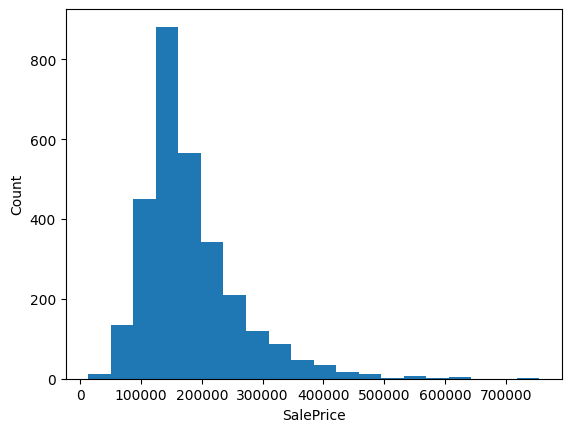

In [66]:
plt.hist(housing_data_raw["SalePrice"], bins=20)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()


The histogram of SalePrice shows that the distribution is positively (right) skewed, with a long tail of higher-priced homes.

In [67]:
housing_data_raw["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

The distribution of SalePrice appears to be right-skewed and unimodal. There is a longer tail toward higher-priced homes, suggesting the presence of more extreme values on the expensive side. This is reflected by the mean SalePrice ($180,796) being greater than the median ($160,000), as high-value properties pull the mean upward.

In [68]:
#numerical variables analysis 
corr=housing_data_raw.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

We will look at the numerical variables with greater than 50% correlation with SalePrice first.

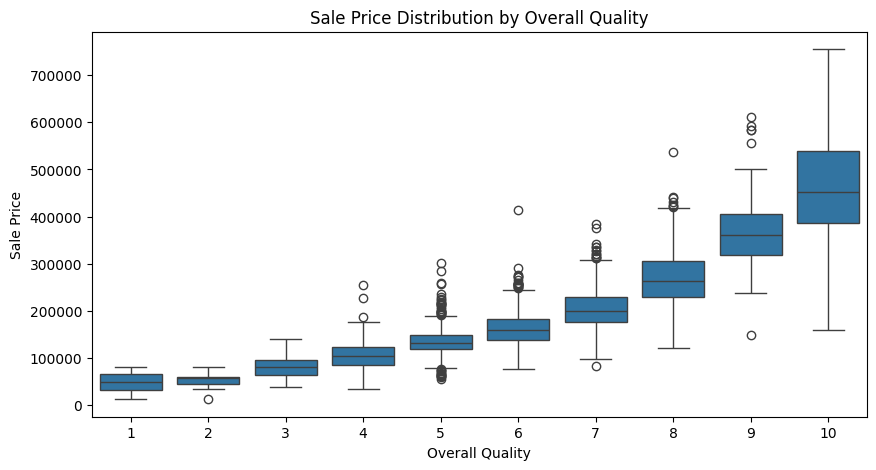

In [69]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Overall Qual",
    y="SalePrice",
    data=housing_data_raw
)

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Sale Price Distribution by Overall Quality")

plt.show()


Since **Overall Quality** is an ordinal categorical variable with values ranging from 1 to 10, a boxplot was used to visualize its relationship with **SalePrice** rather than treating it as a continuous variable. The plot shows a clear positive relationship, with the median sale price increasing as the overall quality rating increases. Homes with an overall quality rating of 10 exhibit the greatest variability in sale prices, whereas homes with ratings of 1 and 2 have the smallest range of sale prices. Additionally, several outliers are present across most quality levels, particularly for ratings between 4 and 7, indicating that some homes within these categories sold for substantially higher prices than the majority of properties with the same quality rating.


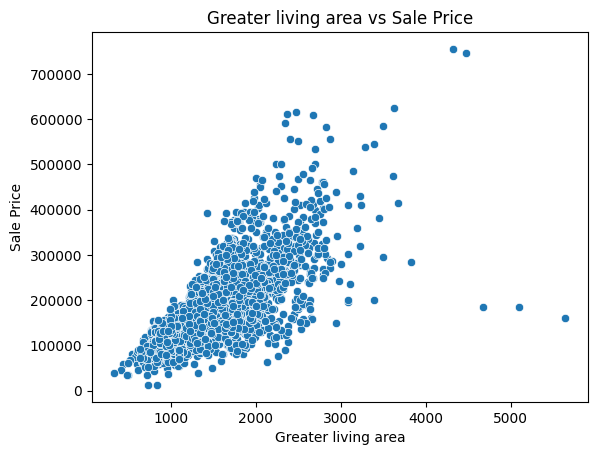

In [70]:
sns.scatterplot(
    data=housing_data_raw,
    x="Gr Liv Area",
    y="SalePrice"
)

plt.title("Greater living area vs Sale Price")
plt.xlabel("Greater living area")
plt.ylabel("Sale Price")
plt.show()

We see from the scatter plot that as greater living area increases, sale price also increases.

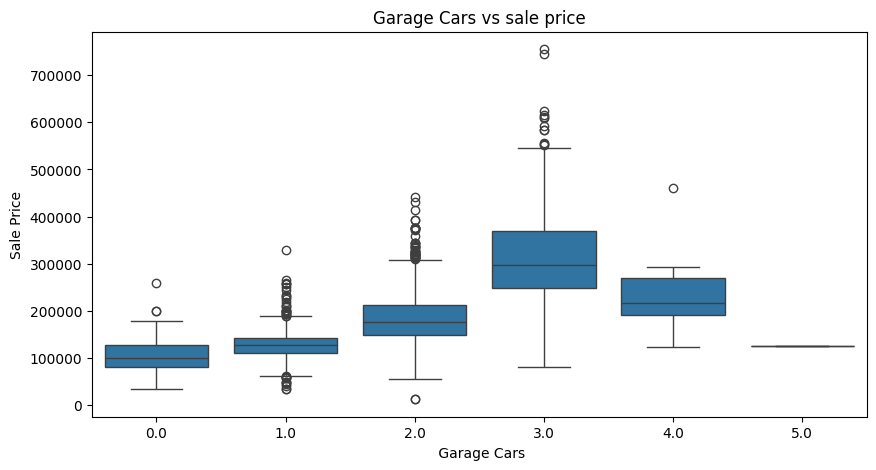

In [71]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Garage Cars",
    y="SalePrice",
    data=housing_data_raw
)

plt.xlabel(" Garage Cars")
plt.ylabel("Sale Price")
plt.title("Garage Cars vs sale price")

plt.show()

The boxplot indicates that **SalePrice** generally increases as the number of garage spaces increases. Homes without a garage have the lowest median sale price, while homes with a three-car garage have the highest median sale price. This suggests a positive relationship between garage capacity and house value. Although homes with four- and five-car garages are present in the dataset, their median sale prices are lower than those of three-car garages, likely due to the relatively small number of observations in these categories. There is also considerable variation in sale prices within each garage size category, with several high-priced outliers observed among homes with larger garage capacities.


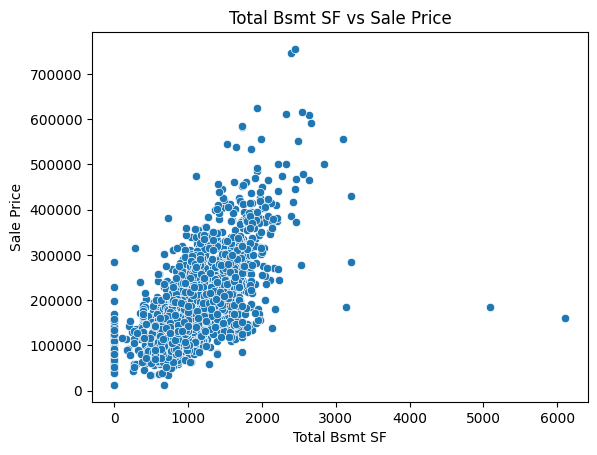

In [72]:
sns.scatterplot(
    data=housing_data_raw,
    x="Total Bsmt SF",
    y="SalePrice"
)

plt.title("Total Bsmt SF vs Sale Price")
plt.xlabel("Total Bsmt SF")
plt.ylabel("Sale Price")
plt.show()

Total Bsmt SF is positively associated with SalePrice, indicating that additional basement space contributes to higher property values. The presence of high-value observations with large basements creates an extended upper range. A small number of properties have no basement (Total Bsmt SF = 0) but still have substantial sale prices, suggesting that above-ground features and other characteristics contribute significantly to home value.

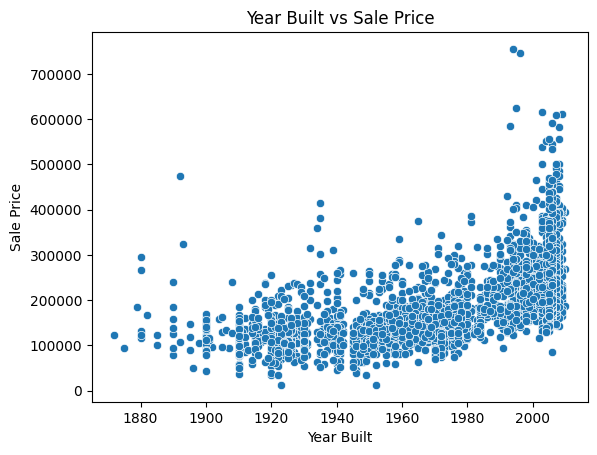

In [73]:
sns.scatterplot(
    data=housing_data_raw,
    x="Year Built",
    y="SalePrice"
)

plt.title("Year Built vs Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")
plt.show()

<Axes: xlabel='Age_Group', ylabel='SalePrice'>

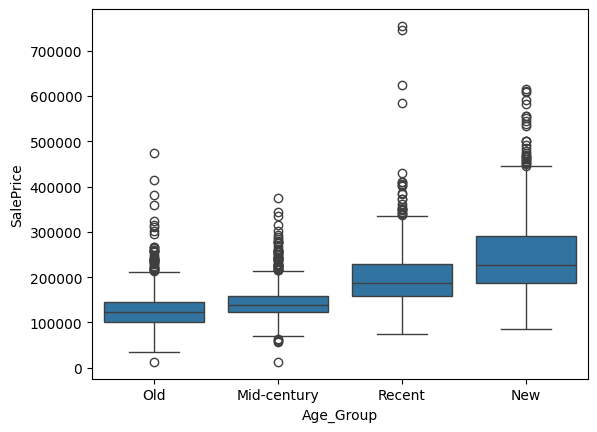

In [74]:
housing_data_raw["Age_Group"] = pd.cut(
    housing_data_raw["Year Built"],
    bins=[1800, 1950, 1975, 2000, 2025],
    labels=["Old", "Mid-century", "Recent", "New"]
)

sns.boxplot(
    x="Age_Group",
    y="SalePrice",
    data=housing_data_raw
)

To better understand the relationship between house age and sale price, the ages of the houses were grouped into four categories: **Old, Mid-century, Recent, and New**. The boxplot shows that **New** homes generally have higher median sale prices than **Old** homes, indicating that newer properties tend to command a premium in the housing market. Across all age groups, most outliers occur on the upper end of the price distribution, suggesting that exceptionally high-priced homes exist regardless of age. However, the highest median sale prices are observed among the **New** homes.


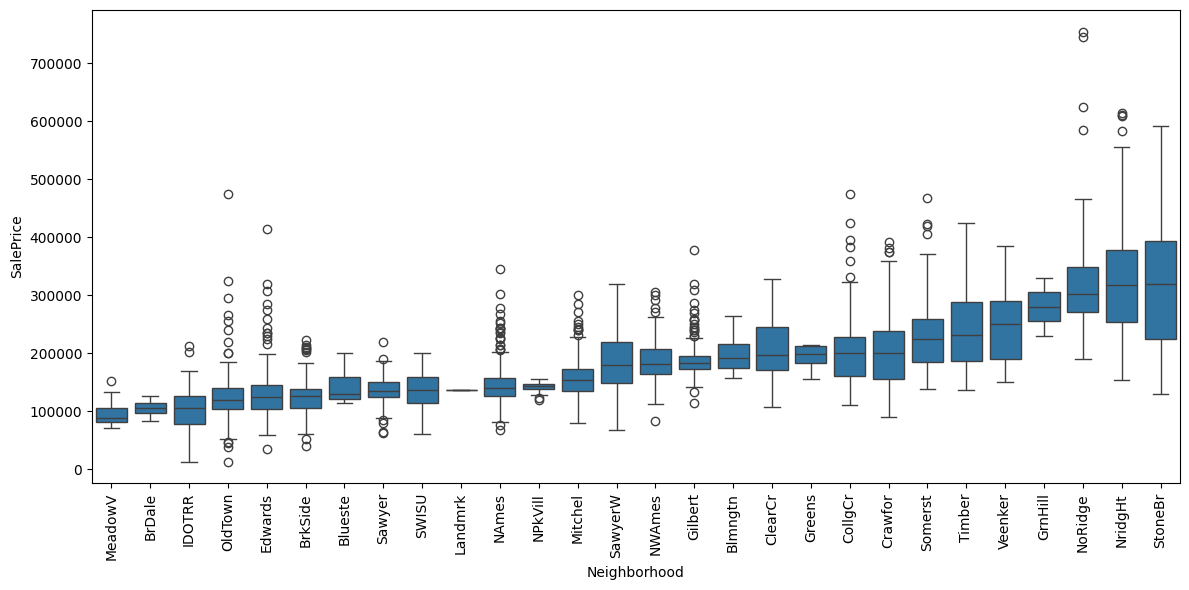

In [75]:
order = (
    housing_data_raw.groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=housing_data_raw,
    order=order
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

These boxplots show how the price varies with different neighbourhoods varying from lowest median to highest median. 

<Axes: xlabel='Exter Cond', ylabel='SalePrice'>

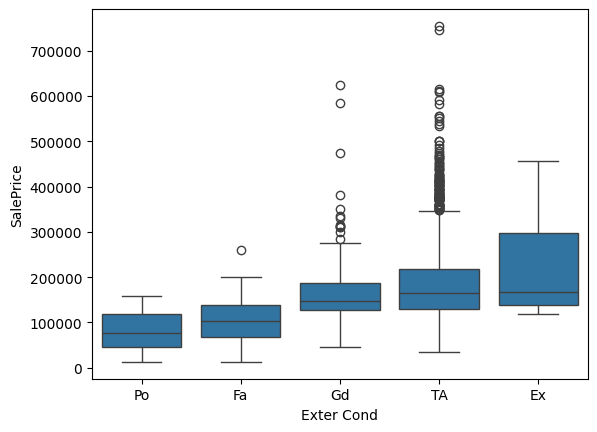

In [76]:
order_ex = (
    housing_data_raw.groupby("Exter Cond")["SalePrice"]
    .median()
    .sort_values()
    .index
)
sns.boxplot(
    x="Exter Cond",
    y="SalePrice",
    data=housing_data_raw,
    order=order_ex
)

The boxplot shows that the median **SalePrice** generally increases as the exterior condition improves, following the order **Po < Fa < TA < Gd < Ex**. Homes rated **Excellent (Ex)** have the highest median sale price, while those rated **Poor (Po)** have the lowest. Interestingly, homes with a **Typical (TA)** exterior condition have a higher median sale price than those rated **Good (Gd)** and exhibit a much wider spread with numerous high-priced outliers. This may be because the majority of homes in the dataset are classified as having a typical exterior condition, resulting in greater variability in sale prices. It also suggests that factors other than exterior condition, such as neighbourhood, overall quality, and living area, have a substantial influence on house prices.


<Axes: xlabel='Bldg Type', ylabel='SalePrice'>

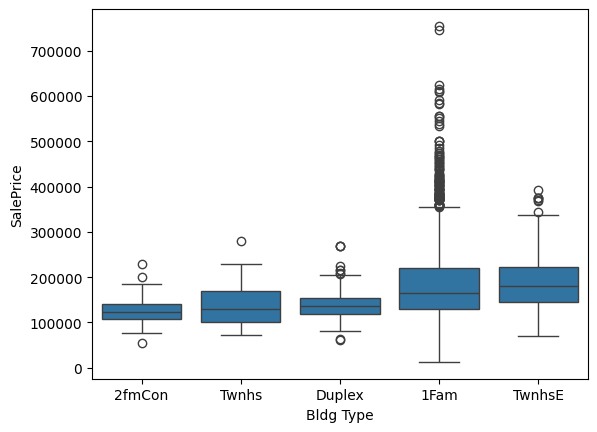

In [77]:

order_building = (
    housing_data_raw.groupby("Bldg Type")["SalePrice"]
    .median()
    .sort_values()
    .index
)
sns.boxplot(
    x="Bldg Type",
    y="SalePrice",
    data=housing_data_raw,
    order=order_building
)

The boxplot shows that **townhouses** have the highest median sale price among the dwelling types, while **one-family houses (1Fam)** also have a relatively high median sale price. In addition, one-family houses exhibit the greatest number of high-priced outliers, indicating a wider range of sale prices within this category. This greater variability is likely due to one-family homes representing the most common dwelling type in the dataset and encompassing a broad range of property sizes, locations, and quality levels.


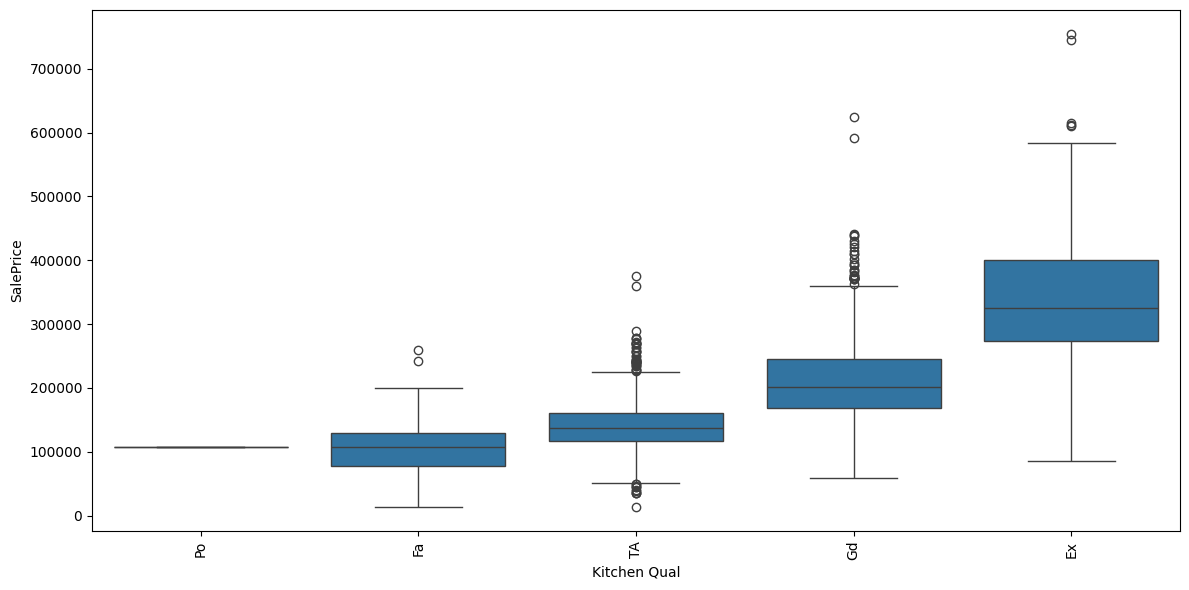

In [78]:
order = (
    housing_data_raw.groupby("Kitchen Qual")["SalePrice"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Kitchen Qual",
    y="SalePrice",
    data=housing_data_raw,
    order=order
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Homes with excellent kitchen quality have the greatest sale price, while those with poor kitchen quality have the lowest.

Outlier check

In [79]:


summary = []

for col in num_cols:
    Q1 = housing_data_raw[col].quantile(0.25)
    Q3 = housing_data_raw[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((housing_data_raw[col] < lower) | (housing_data_raw[col] > upper)).sum()

    summary.append({
        "Variable": col,
        "Outliers": outliers
    })

summary_df = pd.DataFrame(summary).sort_values(
    by="Outliers",
    ascending=False
)

print(summary_df)

           Variable  Outliers
31   Enclosed Porch       459
11     BsmtFin SF 2       351
33     Screen Porch       256
6      Overall Cond       252
2       MS SubClass       208
9      Mas Vnr Area       200
3      Lot Frontage       187
19   Bsmt Half Bath       175
30    Open Porch SF       159
38        SalePrice       137
23    Kitchen AbvGr       134
4          Lot Area       127
13    Total Bsmt SF       123
35         Misc Val       103
22    Bedroom AbvGr        78
17      Gr Liv Area        75
29     Wood Deck SF        67
12      Bsmt Unf SF        56
24    TotRms AbvGrd        51
14       1st Flr SF        43
28      Garage Area        42
16  Low Qual Fin SF        40
32       3Ssn Porch        37
27      Garage Cars        17
10     BsmtFin SF 1        15
25       Fireplaces        13
34        Pool Area        13
7        Year Built         9
15       2nd Flr SF         8
20        Full Bath         4
5      Overall Qual         4
26    Garage Yr Blt         3
18   Bsmt 

<Axes: xlabel='Lot Area', ylabel='SalePrice'>

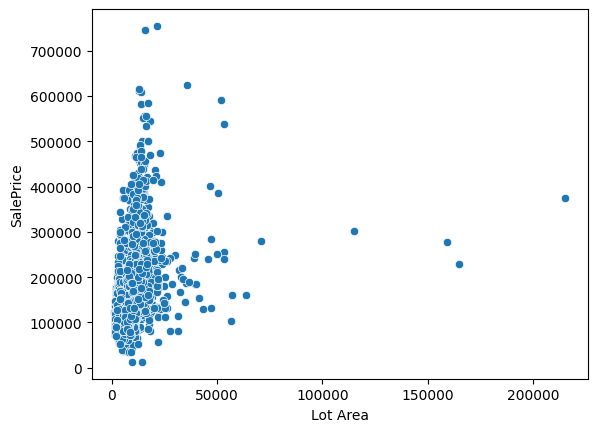

In [80]:
sns.scatterplot(x="Lot Area", y="SalePrice", data=housing_data_raw)

<Axes: xlabel='Total Bsmt SF', ylabel='SalePrice'>

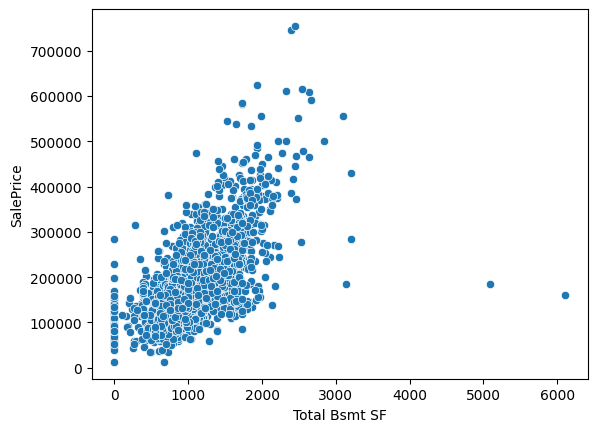

In [81]:
sns.scatterplot(x="Total Bsmt SF", y="SalePrice", data=housing_data_raw)

Potential outliers were identified using the **1.5 × IQR rule** across all numerical variables. Several variables, including **Enclosed Porch, BsmtFin SF 2, and Screen Porch**, had a large number of flagged observations. This was largely due to the presence of many zero values, as many homes do not contain these features, causing the distributions to be highly skewed. For key continuous variables, including **SalePrice, Lot Area, and Total Bsmt SF**, potential outliers were further examined using scatterplots (**Gr Liv Area** was already reviewed during EDA) to determine whether they represented data errors or legitimate high-value properties. Since the identified outliers appeared to reflect genuine variations in property characteristics rather than data entry errors, all observations were retained for subsequent analysis.


As SalePrice is a continuous variable and the predictors are a mixture of categorical and numerical variables, we will start with multiple linear regression.

In [82]:
# Drop IDs and EDA-only Age_Group (created for the year-built boxplot;
# Year Built is kept as the modeling feature)
housing_data_raw = housing_data_raw.drop(
    ["Order", "PID", "Age_Group"],
    axis=1,
    errors="ignore",
)

X = housing_data_raw.drop("SalePrice", axis=1)
Y = housing_data_raw["SalePrice"]
X[cat_cols] = X[cat_cols].fillna("Missing")  # missing category for categorical NA


The variables **Order** and **PID** were removed from the dataset, as they serve as identification variables and do not provide meaningful predictive information for the model. **Age_Group** was also dropped before modeling: it was created only for EDA (the year-built boxplot) and would otherwise be one-hot encoded alongside **Year Built**, adding redundant features. The predictor variables (**X**) and response variable (**Y**, SalePrice) were then assigned. Based on the missingness analysis performed during exploratory data analysis, missing values in categorical variables were handled by assigning them to a separate **"Missing"** category. This approach preserves the information contained in the absence of a feature, as missingness may indicate that a particular property characteristic is not present (e.g., no basement, garage, or additional feature).


In [83]:
# Numerical variables: zero-fill only where missing means "feature absent"
# Lot Frontage median is fit AFTER the train/test split to avoid leakage
zero_cols = [
    "Mas Vnr Area",
    "Bsmt Half Bath",
    "Bsmt Full Bath",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Garage Cars",
    "Garage Area",
]

for col in zero_cols:
    X[col] = X[col].fillna(0)

X["HasGarage"] = (X["Garage Area"] > 0).astype(int)
X["Garage Yr Blt"] = X["Garage Yr Blt"].fillna(0)


Numerical variables where missing values indicated the absence of a feature were imputed with **0**. For example, missing values in basement- and garage-related fields were treated as homes without that feature. A binary indicator, **HasGarage**, was also created from Garage Area.

**Lot Frontage** is different: missingness means the value is unknown, not that frontage is zero. Its median will be estimated from the **training set only** after the train/test split, then applied to both train and test. That avoids leaking test-set information into preprocessing.


In [84]:
# Remaining missing values should be Lot Frontage only (imputed after the split)
remaining_missing = X.isnull().sum()
remaining_missing[remaining_missing > 0]


Lot Frontage    490
dtype: int64

After the zero-fills, the only remaining missing values are in **Lot Frontage**. Those will be imputed after the train/test split using the training-set median.

In [85]:
cat_cols = X.select_dtypes(include=["object","category"]).columns
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

Categorical variables were converted into dummy variables using one-hot encoding to allow them to be incorporated into the regression models. The first dummy variable category was dropped for each categorical feature to prevent perfect multicollinearity, also known as the dummy variable trap. The remaining dummy variables represent comparisons relative to the omitted reference category.


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
)

# Fit Lot Frontage median on TRAIN only, then apply to train and test
X_train = X_train.copy()
X_test = X_test.copy()

lot_frontage_median = X_train["Lot Frontage"].median()
X_train["Lot Frontage"] = X_train["Lot Frontage"].fillna(lot_frontage_median)
X_test["Lot Frontage"] = X_test["Lot Frontage"].fillna(lot_frontage_median)

print("Lot Frontage train median:", lot_frontage_median)
print("Remaining missing (train):", X_train.isnull().sum().sum())
print("Remaining missing (test):", X_test.isnull().sum().sum())


Lot Frontage train median: 68.0
Remaining missing (train): 0
Remaining missing (test): 0


The dataset was divided into training and testing sets using an 80/20 split, with a fixed random state for reproducibility. After the split, missing **Lot Frontage** values were imputed using the median computed from the training set only; that same median was then applied to the test set. This keeps preprocessing consistent with a real deployment setting, where test/future data must not influence training statistics. The training set is used for model fitting and hyperparameter tuning; the test set is reserved for final evaluation.


In [87]:
mlr = LinearRegression()
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
rmse_scores = -cross_val_score(
    mlr,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

print("RMSE for each fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())


RMSE for each fold: [20879.91380018 40913.49011233 43293.05757365 21583.72110852
 46190.27921234]
Mean RMSE: 34572.09236140402
Standard Deviation: 11022.017663993462


Five-fold cross-validation was performed on the initial linear regression model to evaluate model performance and assess its ability to generalize to unseen data. The training dataset was divided into five subsets, where the model was trained on four folds and validated on the remaining fold. This process was repeated five times, and the RMSE values from each fold were averaged to obtain the mean cross-validation RMSE score.


In [88]:
mlr.fit(X_train, y_train)
y_pred = mlr.predict(X_train)
residuals = y_train - y_pred

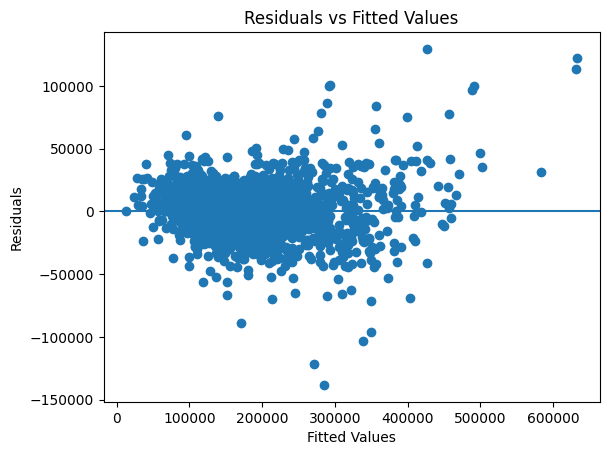

In [89]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


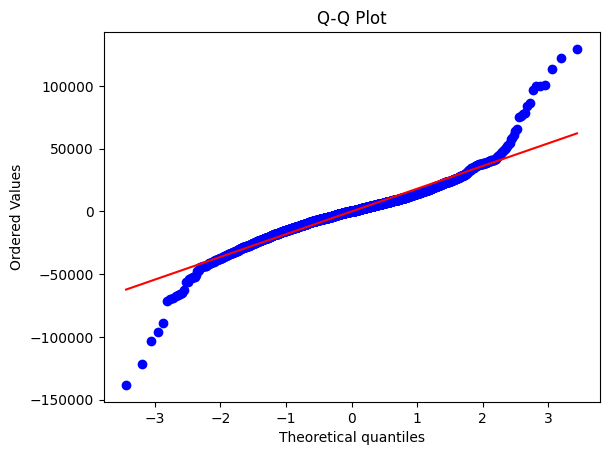

In [90]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()


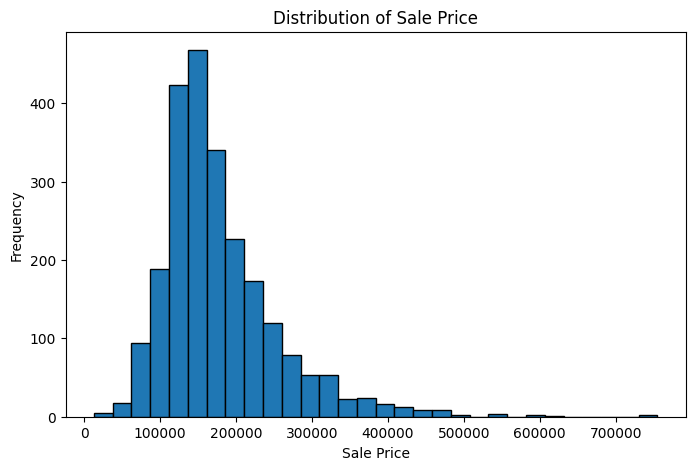

In [91]:
plt.figure(figsize=(8,5))

plt.hist(
    y_train,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of Sale Price")

plt.show()

After fitting the initial linear regression model on the training data, the regression assumptions were evaluated using residual diagnostics.

**Constant variance (homoscedasticity):** The residuals-versus-fitted values plot showed that the spread of residuals increased as predicted SalePrice increased. Residuals were relatively concentrated for lower-priced homes but became more dispersed for higher-priced properties, indicating heteroscedasticity and a violation of the constant variance assumption.

**Normality of residuals:** The Q-Q plot showed that residuals followed the reference line reasonably well in the center but deviated in both tails. This suggests that the residuals are approximately normally distributed in the middle of the distribution but contain heavier tails and potential outliers, indicating a departure from perfect normality.

Because SalePrice was right-skewed during exploratory data analysis and the regression assumptions were not fully satisfied, a log transformation of the response variable, log(1+SalePrice), was applied to evaluate whether it improved residual behavior and model performance.


In [92]:
# Reuse the same train/test rows; only transform the target
# (avoids re-splitting from X and undoing train-only Lot Frontage imputation)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

mlr = LinearRegression()

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

rmse_scores = -cross_val_score(
    mlr,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
)

print("CV RMSE:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())


CV RMSE: [0.12423501 0.18951933 0.19157438 0.121721   0.2418236 ]
Mean CV RMSE: 0.17377466493490998


In [93]:
mlr.fit(X_train, y_train_log)
y_train_pred_log = mlr.predict(X_train)
residuals_log = y_train_log - y_train_pred_log

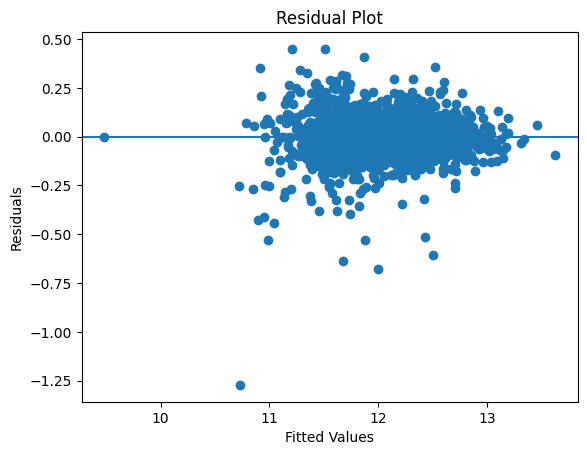

In [94]:
plt.scatter(
    y_train_pred_log,
    residuals_log
)

plt.axhline(0)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



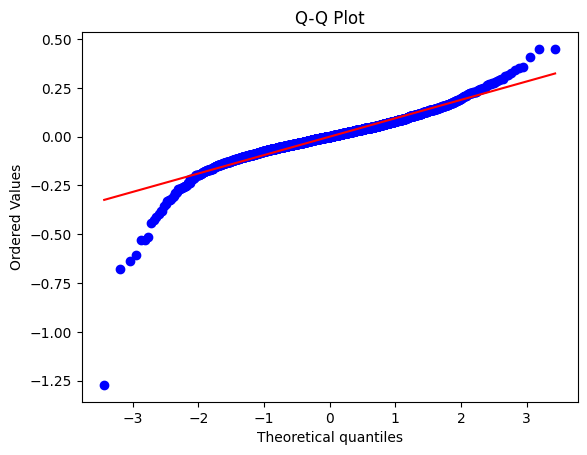

In [95]:
stats.probplot(residuals_log, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

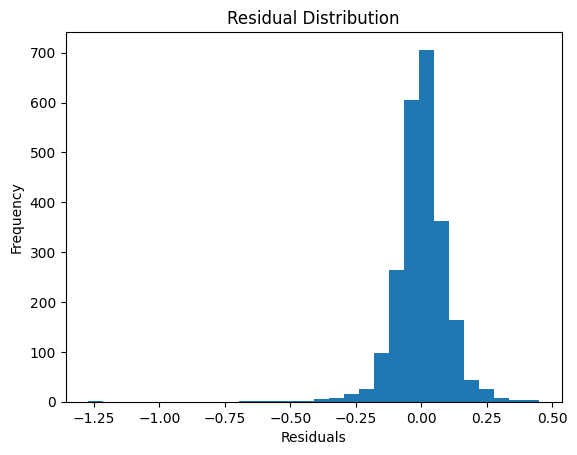

In [96]:
plt.hist(
    residuals_log,
    bins=30
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

After applying the log1p transformation to **SalePrice**, five-fold cross-validation was performed on the linear regression model. The RMSE values from each fold were averaged to obtain the mean cross-validation RMSE score. Residual diagnostics were then evaluated to assess whether the regression assumptions improved.

The residual-versus-fitted plot showed that the constant variance assumption was better satisfied after the transformation, with a more consistent spread of residuals across predicted values. The Q-Q plot also showed improvement in residual normality compared to the initial model; however, some deviations remained in the tails, indicating the presence of heavier-tailed residuals and potential outliers. Overall, the log1p transformation improved the regression assumptions compared to the original SalePrice model.


In [97]:
y_pred_log = mlr.predict(X_test)

test_mse = mean_squared_error(
    y_test_log,
    y_pred_log
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test_log,
    y_pred_log
)

print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)


Test RMSE: 0.16463782534619426
Test R²: 0.853506357180917


The final model performance was evaluated on the independent test dataset using the test RMSE and R² metrics. The model was trained using the training data and then used to generate predictions on the unseen test data. Test RMSE was calculated to measure the average prediction error, while R² was calculated to determine the proportion of variability in the log-transformed SalePrice explained by the model.


VIF check for multicollinearity 

In [98]:
# Use the same matrix you fit on (numeric only)
X_vif = X_train.astype(float).copy()
# Drop constant / near-constant columns (VIF needs full rank)
X_vif = X_vif.loc[:, X_vif.std() > 0]
vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)
print(vif.head(20))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                    feature           VIF
15              Gr Liv Area           inf
242     Garage Cond_Missing           inf
232   Garage Finish_Missing           inf
134    Exterior 1st_PreCast           inf
149    Exterior 2nd_PreCast           inf
237     Garage Qual_Missing           inf
188  BsmtFin Type 1_Missing           inf
173       Bsmt Qual_Missing           inf
8              BsmtFin SF 1           inf
9              BsmtFin SF 2           inf
10              Bsmt Unf SF           inf
11            Total Bsmt SF           inf
12               1st Flr SF           inf
13               2nd Flr SF           inf
14          Low Qual Fin SF           inf
178       Bsmt Cond_Missing           inf
35                  Yr Sold  1.312688e+05
5                Year Built  6.186815e+04
6            Year Remod/Add  3.124411e+04
24            Garage Yr Blt  3.018460e+04


Variance Inflation Factor (VIF) scores were calculated to assess the presence of multicollinearity among predictors. The results showed that several variables had very high VIF values, with some predictors having infinite VIF values, indicating strong linear relationships among features. Rather than manually removing variables based solely on VIF values, regularization techniques were applied to address multicollinearity while preserving potentially important predictors. Ridge regression, Lasso regression, and Elastic Net regression were compared using cross-validation RMSE to determine which approach provided the best predictive performance.


In [99]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

results = []

for alpha in alphas:
    
    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])
    
    rmse = -cross_val_score(
        ridge_pipeline,
        X_train,
        y_train_log,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()
    
    results.append([alpha, rmse])

ridge_results = pd.DataFrame(
    results,
    columns=["Alpha", "RMSE"]
)

ridge_results.sort_values("RMSE")


,Alpha,RMSE
6,1000.000,0.145755
5,100.000,0.148478
4,10.000,0.158316
3,1.000,0.174116
2,0.100,0.179671
1,0.010,0.180462
0,0.001,0.180545


In [100]:
ridge_final = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1000))
])

ridge_final.fit(
    X_train,
    y_train_log
)
y_pred_ridge = ridge_final.predict(X_test)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_log,
        y_pred_ridge
    )
)

test_r2 = r2_score(
    y_test_log,
    y_pred_ridge
)

print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)


Test RMSE: 0.12410464641827873
Test R²: 0.9167593199093468


For Ridge regression, multiple alpha values were evaluated using five-fold cross-validation to determine the optimal level of regularization. Among the tested values, an alpha of **1000** produced the lowest average cross-validation RMSE of **0.145755**. This alpha value was selected as the final Ridge model hyperparameter and was used to fit the training data. The final model was then evaluated on the independent test dataset using test RMSE and R² to assess its predictive performance on unseen data.


In [101]:
alphas = [
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.05,
    0.1
]

results = []

for alpha in alphas:
    
    lasso_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=10000))
    ])
    
    rmse = -cross_val_score(
        lasso_pipeline,
        X_train,
        y_train_log,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()
    
    results.append([alpha, rmse])

lasso_results = pd.DataFrame(
    results,
    columns=["Alpha", "RMSE"]
)

lasso_results.sort_values("RMSE")


,Alpha,RMSE
3,0.0050,0.147093
4,0.0100,0.150917
2,0.0010,0.153874
1,0.0005,0.161235
0,0.0001,0.174673
5,0.0500,0.181462
6,0.1000,0.222052


In [102]:
lasso_final = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.005, max_iter=10000))
])

lasso_final.fit(
    X_train,
    y_train_log
)
lasso_model = lasso_final.named_steps["lasso"]

lasso_coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_model.coef_
})

selected = lasso_coef[
    lasso_coef["Coefficient"] != 0
]

print("Features selected:", selected.shape[0])


Features selected: 87


In [103]:
y_pred_lasso = lasso_final.predict(X_test)

test_rmse_lasso = np.sqrt(
    mean_squared_error(
        y_test_log,
        y_pred_lasso
    )
)

test_r2_lasso = r2_score(
    y_test_log,
    y_pred_lasso
)

print("Test RMSE:", test_rmse_lasso)
print("Test R²:", test_r2_lasso)

Test RMSE: 0.1276427260967165
Test R²: 0.9119454750215731


For Lasso regression, the same approach was followed by evaluating multiple alpha values using five-fold cross-validation. Lasso regression was evaluated because, in addition to reducing the impact of multicollinearity, it can shrink some coefficients exactly to zero, allowing for automatic feature selection while maintaining model interpretability. An alpha value of **0.005** produced the lowest average cross-validation RMSE of **0.147093** and was selected as the optimal regularization parameter. The final Lasso model was then fitted using this alpha value and evaluated on the independent test dataset. The model achieved a test RMSE of **0.127643** and a test R² of **0.911945**, indicating that the model explained approximately 91.2% of the variability in the log-transformed SalePrice values on unseen data.


In [104]:
alphas = [0.0001, 0.001, 0.01, 0.1]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

for alpha in alphas:
    for l1_ratio in l1_ratios:
        elastic = Pipeline([
            ("scaler", StandardScaler()),
            ("elastic", ElasticNet(
                alpha=alpha,
                l1_ratio=l1_ratio,
                max_iter=10000,
            )),
        ])

        rmse = -cross_val_score(
            elastic,
            X_train,
            y_train_log,
            cv=5,
            scoring="neg_root_mean_squared_error",
        ).mean()

        results.append([alpha, l1_ratio, rmse])

elastic_results = pd.DataFrame(
    results,
    columns=["Alpha", "L1_ratio", "RMSE"],
)

elastic_results.sort_values("RMSE").head()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.834e-02, tolerance: 3.038e-02
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.833e-02, tolerance: 3.060e-02
  model = cd_fast.enet_coordinate_descent(


,Alpha,L1_ratio,RMSE
11,0.01,0.3,0.144186
12,0.01,0.5,0.144473
13,0.01,0.7,0.146091
10,0.01,0.1,0.147482
15,0.10,0.1,0.148609


In [105]:
elastic_final = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(
        alpha=0.01,
        l1_ratio=0.3,
        max_iter=10000
    ))
])

elastic_final.fit(
    X_train,
    y_train_log
)

y_pred_elastic = elastic_final.predict(X_test)

test_rmse_elastic = np.sqrt(
    mean_squared_error(
        y_test_log,
        y_pred_elastic
    )
)

test_r2_elastic = r2_score(
    y_test_log,
    y_pred_elastic
)

print("Test RMSE:", test_rmse_elastic)
print("Test R²:", test_r2_elastic)


Test RMSE: 0.12730837214477392
Test R²: 0.912406179977949


Elastic Net regression was also evaluated, as it combines the benefits of both Ridge and Lasso regression by applying a combination of L2 and L1 regularization. This allows Elastic Net to reduce the impact of multicollinearity while also performing variable selection by shrinking some coefficients toward zero. Multiple combinations of alpha and l1_ratio values were tested using five-fold cross-validation. The combination of **alpha = 0.01** and **l1_ratio = 0.3** produced the lowest average cross-validation RMSE of **0.144186** and was selected as the optimal parameter combination. The final Elastic Net model was then fitted using these parameters and evaluated on the independent test dataset. The model achieved a test RMSE of **0.127308** and a test R² of **0.912406**, indicating that it explained approximately 91.2% of the variability in the log-transformed SalePrice values on unseen data.


### Linear Models So Far

At this stage, the linear models have been evaluated on the log-transformed SalePrice scale:

| Model | Test RMSE (log) | Test R² | Role |
| ----- | --------------: | ------: | ---- |
| Linear Regression | 0.165 | 0.854 | Baseline |
| **Ridge (α=1000)** | **0.124** | **0.917** | **Best linear / interpretable** |
| Lasso (α=0.005) | 0.128 | 0.912 | Feature selection |
| Elastic Net (α=0.01, l1_ratio=0.3) | 0.127 | 0.912 | Hybrid linear approach |

Ridge is selected as the strongest linear model for coefficient interpretation. Tree-based models (Random Forest and XGBoost) are evaluated next to test whether nonlinear methods can further improve predictive accuracy. A full comparison table appears in the conclusion.


Among the linear models, Ridge regression with an alpha value of **1000** achieved the best predictive performance on the independent test dataset. Compared with Lasso and Elastic Net, Ridge produced the lowest test RMSE (**0.124**) and the highest test R² (**0.917**) on the log-transformed SalePrice scale. Ridge was therefore selected as the strongest **interpretable linear model** and used for coefficient interpretation. A Random Forest model is evaluated next to determine whether a nonlinear ensemble can further improve predictive accuracy.


In [106]:
# Convert predictions back to original SalePrice scale

y_pred_original = np.expm1(y_pred_ridge)
y_test_original = np.expm1(y_test_log)

dollar_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred_original
    )
)

print("Dollar RMSE:", dollar_rmse)

Dollar RMSE: 32765.30889912845


In [107]:
dollar_mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

print("Dollar MAE:", dollar_mae)


Dollar MAE: 16822.1841777775


After converting the log-transformed predictions back to the original SalePrice scale using the inverse transformation, the final Ridge regression model achieved a dollar RMSE of approximately **$32,765** and a dollar MAE of approximately **$16,822**. RMSE penalizes larger errors more heavily, while MAE reflects the typical absolute size of the prediction error. On average, the model's predicted home prices differ from the actual sale prices by about **$16,822** (MAE). While the log-scale metrics are useful for comparing models, the dollar RMSE and MAE provide a more practical interpretation of prediction error in real-world housing price terms.


In [108]:
ridge_model = ridge_final.named_steps["ridge"]

ridge_interpretation = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.coef_
})

ridge_interpretation["Percent_Change"] = (
    (np.exp(ridge_interpretation["Coefficient"]) - 1) * 100
)

ridge_interpretation["Absolute_Coefficient"] = (
    ridge_interpretation["Coefficient"].abs()
)

ridge_interpretation.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(20).reset_index(drop=True)


,Feature,Coefficient,Percent_Change,Absolute_Coefficient
0,Overall Qual,0.047366,4.850593,0.047366
1,Gr Liv Area,0.036386,3.705572,0.036386
2,1st Flr SF,0.026979,2.734659,0.026979
3,Overall Cond,0.025653,2.598525,0.025653
4,Full Bath,0.020691,2.090694,0.020691
5,Total Bsmt SF,0.020576,2.078871,0.020576
6,Neighborhood_NridgHt,0.019809,2.000683,0.019809
7,Garage Cars,0.019297,1.948445,0.019297
8,2nd Flr SF,0.018638,1.881314,0.018638
9,TotRms AbvGrd,0.018222,1.838857,0.018222


The Ridge regression coefficients were interpreted by converting the coefficients from the log-transformed model into approximate percentage changes in SalePrice. The strongest positive predictors were related to overall property quality, size, and features. **Overall Qual** had the largest positive association, with a one standard deviation increase associated with an approximate **4.9% increase** in SalePrice, followed by **Gr Liv Area** (**3.7% increase**) and **1st Flr SF** (**2.7% increase**). Other important positive predictors included **Overall Cond**, **Full Bath**, **Total Bsmt SF**, **Garage Cars**, and neighborhood indicators such as **Neighborhood_NridgHt**, highlighting the importance of house quality, size, amenities, and location in determining property value.

The strongest negative predictors were associated with lower-quality features and less desirable property characteristics. **Functional_Sal** showed the largest negative association, corresponding to an approximate **1.7% decrease** in SalePrice compared with the reference category. Other negative predictors included **Misc Val**, **MS Zoning_C (all)**, **Kitchen Qual_TA**, and **Neighborhood_MeadowV**, suggesting that functionality, zoning, kitchen quality, and neighborhood characteristics negatively influence predicted housing prices. Overall, the Ridge model identified property quality, living area, and neighborhood as the strongest contributors to housing value.


## Random Forest

Random Forest was added to capture nonlinear effects and interactions among predictors that linear models may miss, while still providing useful feature-importance rankings for interpretation.


In [109]:
param_grid = {
    "n_estimators": [300,500],
    "max_depth": [None,10,20,],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    n_iter=10,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(
    X_train,
    y_train_log
)
best_cv_rmse = -rf_search.best_score_
print("Best CV RMSE:", best_cv_rmse)


Best CV RMSE: 0.14304910432150342


In [110]:
# Best model from RandomizedSearchCV
best_rf = rf_search.best_estimator_

# Predictions
train_pred_rf_log = best_rf.predict(X_train)
y_pred_rf_log = best_rf.predict(X_test)

# Metrics on log-transformed target
train_rmse_rf_log = np.sqrt(mean_squared_error(y_train_log, train_pred_rf_log))
test_rmse_rf_log = np.sqrt(mean_squared_error(y_test_log, y_pred_rf_log))
test_r2_rf = r2_score(y_test_log, y_pred_rf_log)

# Convert predictions back to original SalePrice scale
y_pred_rf = np.expm1(y_pred_rf_log)
y_test_actual = np.expm1(y_test_log)

# RMSE on original SalePrice scale
test_rmse_rf_dollar = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))

print("Best Parameters:", rf_search.best_params_)
print("Train RMSE (log scale):", train_rmse_rf_log)
print("Test RMSE (log scale):", test_rmse_rf_log)
print("Test R² (log scale):", test_r2_rf)
print("Test RMSE ($):", test_rmse_rf_dollar)


Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Train RMSE (log scale): 0.06365822544564663
Test RMSE (log scale): 0.12278348708066632
Test R² (log scale): 0.918522168251817
Test RMSE ($): 27227.750558033968


In [111]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
3,Overall Qual,0.600198
15,Gr Liv Area,0.085150
25,Garage Cars,0.046144
26,Garage Area,0.032328
12,1st Flr SF,0.031729
11,Total Bsmt SF,0.029987
8,BsmtFin SF 1,0.015740
2,Lot Area,0.013520
5,Year Built,0.013107
6,Year Remod/Add,0.011192


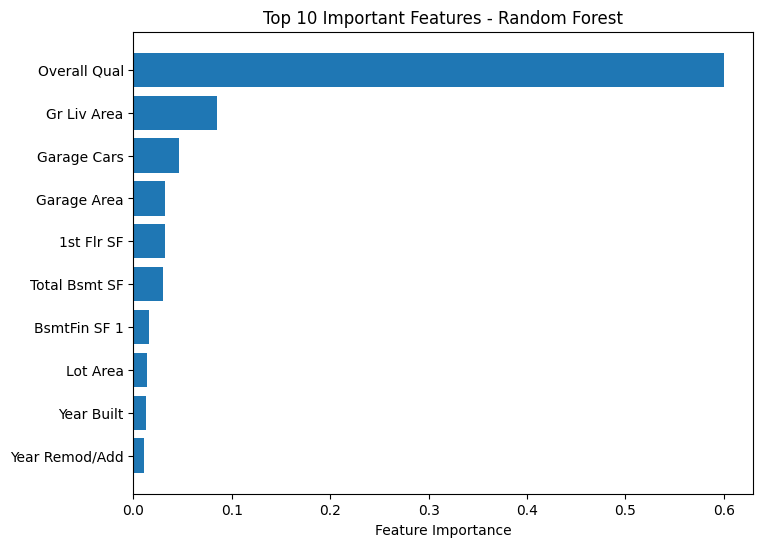

In [112]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()


A Random Forest Regressor was tuned using Randomized Search with 5-fold cross-validation to capture nonlinear effects and feature interactions. The optimal model used **500** trees, no maximum depth, a minimum of **2** samples per leaf, and **2** samples required to split a node.

On the log-transformed SalePrice scale, the model achieved a cross-validation RMSE of **0.143**, a test RMSE of **0.123**, and a test R² of **0.919**. On the original dollar scale, the test RMSE was approximately **$27,228**. The training log RMSE (**0.064**) was lower than the test log RMSE (**0.123**), indicating mild overfitting, though test performance remained strong.

Relative to Ridge regression (test log RMSE **0.124**, dollar RMSE **~$32,765**), Random Forest improved predictive accuracy, especially on the dollar scale. Feature importance analysis showed that **Overall Qual** was the most influential predictor, followed by **Gr Liv Area**, garage-related features (**Garage Cars**, **Garage Area**), and other size/quality measures.


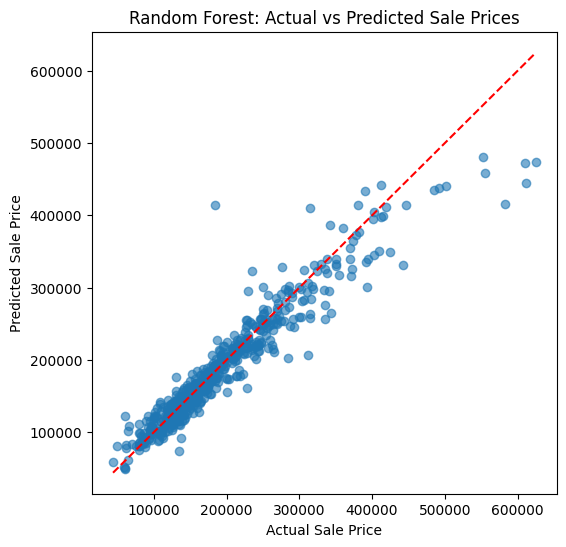

In [113]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_rf, alpha=0.6)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    "r--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Random Forest: Actual vs Predicted Sale Prices")
plt.show()


The actual-versus-predicted plot compares Random Forest predictions to true SalePrice values on the test set. Points closer to the red dashed line (perfect prediction) indicate more accurate estimates. Most homes cluster near the line, especially in the mid-price range, which is consistent with the model's strong test performance. Larger misses are more common at the high end of the price range, where expensive homes are harder to predict and contribute more to dollar RMSE. Overall, the plot supports that the Random Forest captures the main price pattern well, with remaining error concentrated among higher-valued properties.

In [114]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best CV RMSE: 0.12456804755031


In [115]:
xgb_final = grid.best_estimator_
y_pred_xgb = xgb_final.predict(X_test)
test_rmse = np.sqrt(
    mean_squared_error(
        y_test_log,
        y_pred_xgb
    )
)

test_r2 = r2_score(
    y_test_log,
    y_pred_xgb
)

print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test RMSE: 0.10675823371378491
Test R²: 0.938402612017762


To improve predictive performance beyond traditional linear models, an XGBoost regression model was developed using the log-transformed SalePrice as the response variable. Unlike linear regression models, XGBoost is a tree-based ensemble method capable of capturing nonlinear relationships and interactions among predictors without requiring feature scaling. Hyperparameter tuning was performed using 5-fold cross-validation to identify the optimal combination of model parameters, including the number of trees (n_estimators), tree depth (max_depth), learning rate, row sampling (subsample), and feature sampling (colsample_bytree). The final model was trained using the optimal parameters: 500 estimators, a learning rate of 0.05, a maximum depth of 3, and 0.8 sampling for both observations and features. The final XGBoost model achieved a cross-validation RMSE of 0.125 on the log scale and a test RMSE of 0.107 with an R² of 0.938.

In [116]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_final.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
).head(20)

,Feature,Importance
3,Overall Qual,0.105949
25,Garage Cars,0.093290
15,Gr Liv Area,0.051475
41,MS Zoning_RL,0.051410
23,Fireplaces,0.050757
249,Paved Drive_Y,0.047901
207,Central Air_Y,0.047188
42,MS Zoning_RM,0.043087
5,Year Built,0.035716
216,Kitchen Qual_TA,0.031931


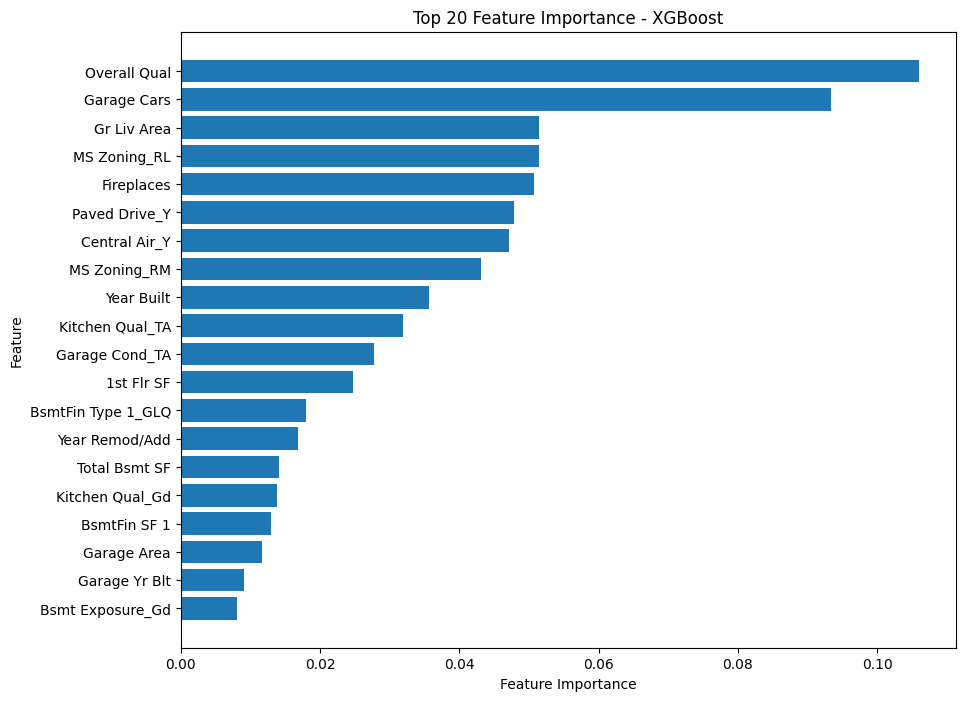

In [117]:
# Create feature importance dataframe
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_final.feature_importances_
})

# Sort and select top 20 features
top_features = (
    xgb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(20)
)

# Plot
plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance - XGBoost")

plt.show()


Feature importance analysis showed that Overall Quality was the most influential predictor in the XGBoost model, followed by Garage Cars, above-ground living area, zoning classification, fireplaces, paved driveway, central air availability, year built, and kitchen quality. These results align with expected housing valuation patterns, where overall construction quality, size, amenities, and location characteristics strongly influence sale price. Unlike linear regression models, feature importance values in XGBoost represent the contribution of each feature to reducing prediction error across the ensemble of decision trees and should not be interpreted as direct increases or decreases in house price.

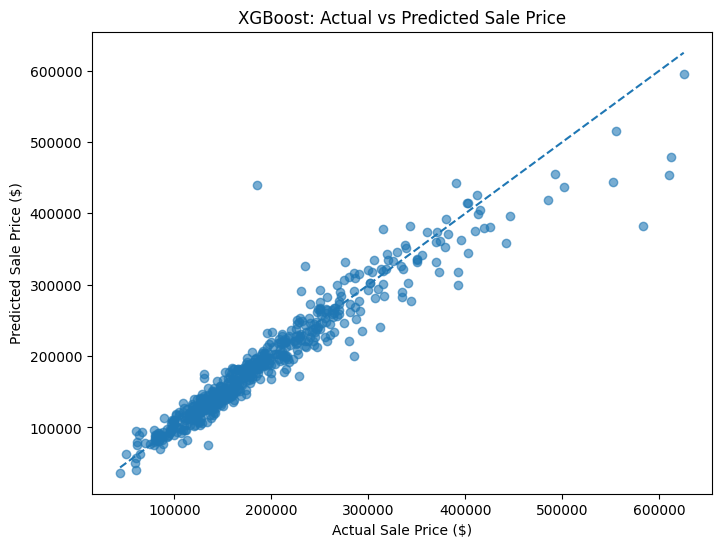

In [118]:
# Convert log predictions back to original price scale
y_test_price = np.expm1(y_test_log)
y_pred_price = np.expm1(y_pred_xgb)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_price,
    y_pred_price,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test_price.min(), y_test_price.max()],
    [y_test_price.min(), y_test_price.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.title("XGBoost: Actual vs Predicted Sale Price")

plt.show()


The actual-versus-predicted plot compares XGBoost’s predicted SalePrice values to the true prices on the test set. Points near the dashed line represent accurate predictions. Most observations cluster tightly around this line across the price range, which is consistent with the model’s strong test performance (RMSE = 0.107, R² = 0.938 on the log scale). Some larger deviations appear among higher-priced homes, where prediction is harder and a small number of expensive properties can increase dollar RMSE. Overall, the plot shows that XGBoost captures the relationship between housing features and SalePrice well, with less scatter than the earlier linear and Random Forest models.

### Model Comparison (Test Set, log SalePrice)

| Model | CV RMSE | Test RMSE ↓ | Test R² ↑ | Dollar RMSE | Notes |
| ----- | ------: | ----------: | --------: | ----------: | ----- |
| Linear Regression | 0.174 | 0.165 | 0.854 | — | Baseline |
| Ridge (α=1000) | 0.146 | 0.124 | 0.917 | $32,765 | Best linear / interpretable |
| Lasso (α=0.005) | 0.147 | 0.128 | 0.912 | — | Feature selection |
| Elastic Net (α=0.01, l1_ratio=0.3) | 0.144 | 0.127 | 0.912 | — | Hybrid linear approach |
| Random Forest | 0.143 | 0.123 | 0.919 | $27,228 | Strong nonlinear baseline |
| **XGBoost** | **0.125** | **0.107** | **0.938** | **$25,047** | **Best overall prediction** |

**Summary:** XGBoost achieved the best predictive performance on the test set, with the lowest log-scale RMSE (**0.107**) and the highest R² (**0.938**). Random Forest was the next-best model. Among linear models, Ridge performed best and remains the most interpretable option.

Overall Model Comparison and Conclusion

Several regression approaches were evaluated to predict house sale prices, including Linear Regression, Ridge Regression, Lasso Regression, Elastic Net, Random Forest, and XGBoost. Linear Regression was initially used as a baseline model, achieving a test RMSE of 0.165 and an R² of 0.854 on the log-transformed SalePrice scale. However, violations of linear regression assumptions and the presence of multicollinearity motivated the use of regularization techniques. Among the linear models, Ridge Regression achieved the strongest performance, with a test RMSE of 0.124 and an R² of 0.917, while maintaining interpretability through standardized coefficients. Lasso and Elastic Net provided similar performance but did not improve upon Ridge.

Tree-based ensemble models were then evaluated to capture nonlinear relationships and interactions among housing characteristics. Random Forest achieved improved predictive performance compared with the linear models, with a test RMSE of 0.123 and an R² of 0.919. XGBoost achieved the best overall performance, reducing the test RMSE to 0.107 and increasing the R² to 0.938. The lower prediction error and higher explained variance indicate that XGBoost was better able to capture complex relationships between housing features and sale prices.

Feature importance analysis from both Random Forest and XGBoost identified Overall Quality as the most influential predictor of house prices. Other consistently important predictors across both tree-based models included Gr Liv Area, Garage Cars, Garage Area, Total Basement SF, First Floor SF, Year Built, and Central Air availability, suggesting that property quality, size, amenities, and age are key determinants of housing value. While Random Forest placed substantially more emphasis on Overall Quality, XGBoost distributed importance more broadly among garage capacity, living area, zoning, fireplaces, and other categorical features, reflecting its ability to capture more complex feature interactions.

Overall, XGBoost was selected as the final predictive model due to its superior predictive accuracy, achieving a test RMSE of approximately $25,047 on the original price scale and explaining 93.8% of the variance in log-transformed sale prices. However, Ridge Regression remains valuable as an interpretable alternative for understanding the direction and relative effect of predictors. Together, the results demonstrate that while linear models provide transparency, advanced tree-based ensemble methods can achieve improved prediction by modeling nonlinear patterns and interactions present in real-world housing data.